In [1]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from skimage.feature import hog
print("Libraries Installed!")

Libraries Installed!


In [2]:
dataset_path = "leapGestRecog"

In [6]:
import os

print(os.getcwd())

c:\Users\Dhanu Sree\OneDrive\Desktop\Internship\Task-4\Hand Gesture Recognition


In [10]:
import os

print(os.listdir())

['HandGestureRecognition.ipynb', 'leapGestRecog']


In [8]:
gesture_counts = {}

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(person_path, gesture)

        count = len(os.listdir(gesture_path))

        gesture_counts[gesture] = (
            gesture_counts.get(gesture,0)
            + count
        )

df = pd.DataFrame(
    gesture_counts.items(),
    columns=["Gesture","Count"]
)

df

,Gesture,Count
0,01_palm,200
1,02_l,200
2,03_fist,7


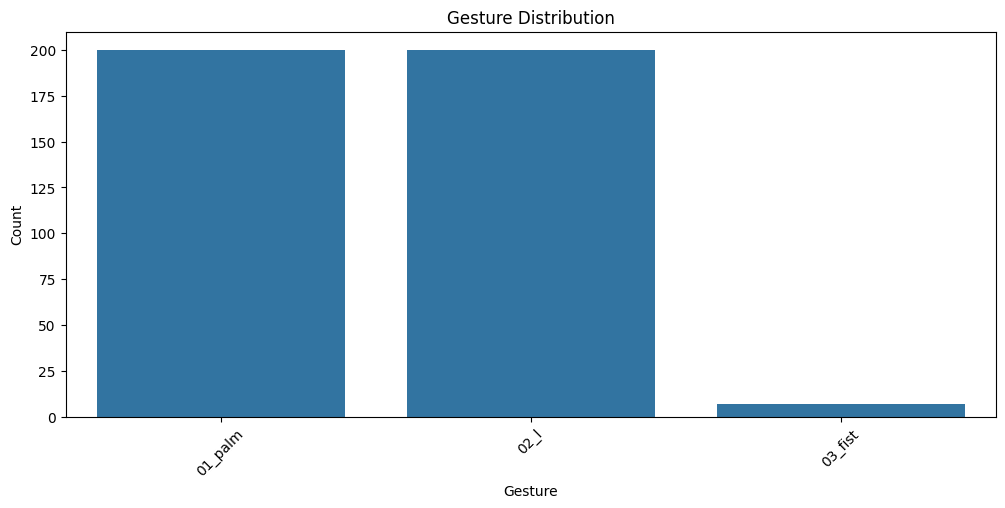

In [9]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=df["Gesture"],
    y=df["Count"]
)

plt.xticks(rotation=45)
plt.title("Gesture Distribution")
plt.show()

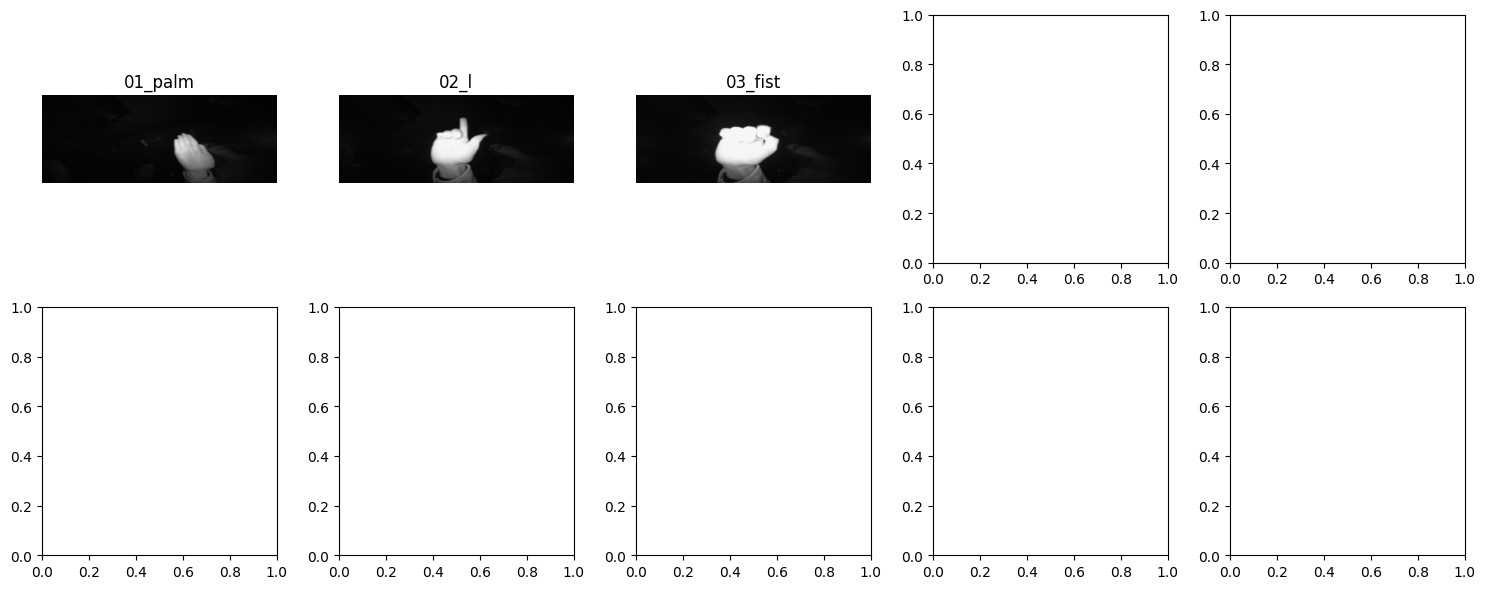

In [11]:
fig, axes = plt.subplots(2,5, figsize=(15,6))

i = 0

for gesture in gesture_counts.keys():

    person = os.listdir(dataset_path)[0]

    img_folder = os.path.join(
        dataset_path,
        person,
        gesture
    )

    img_name = os.listdir(img_folder)[0]

    img = cv2.imread(
        os.path.join(img_folder,img_name)
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[i//5,i%5].imshow(img)
    axes[i//5,i%5].set_title(gesture)
    axes[i//5,i%5].axis("off")

    i += 1

plt.tight_layout()
plt.show()

In [12]:
X = []
y = []

In [14]:
for person in os.listdir(dataset_path):

    person_path = os.path.join(
        dataset_path,
        person
    )

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(
            person_path,
            gesture
        )

        for image in os.listdir(gesture_path):

            img_path = os.path.join(
                gesture_path,
                image
            )

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            img = cv2.resize(
                img,
                (128,128)
            )

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                visualize=False
            )

            X.append(features)
            y.append(gesture)
            print("Samples:", len(X))
            print("Feature Length:", len(X[0]))

Samples: 408
Feature Length: 8100
Samples: 409
Feature Length: 8100
Samples: 410
Feature Length: 8100
Samples: 411
Feature Length: 8100
Samples: 412
Feature Length: 8100
Samples: 413
Feature Length: 8100
Samples: 414
Feature Length: 8100
Samples: 415
Feature Length: 8100
Samples: 416
Feature Length: 8100
Samples: 417
Feature Length: 8100
Samples: 418
Feature Length: 8100
Samples: 419
Feature Length: 8100
Samples: 420
Feature Length: 8100
Samples: 421
Feature Length: 8100
Samples: 422
Feature Length: 8100
Samples: 423
Feature Length: 8100
Samples: 424
Feature Length: 8100
Samples: 425
Feature Length: 8100
Samples: 426
Feature Length: 8100
Samples: 427
Feature Length: 8100
Samples: 428
Feature Length: 8100
Samples: 429
Feature Length: 8100
Samples: 430
Feature Length: 8100
Samples: 431
Feature Length: 8100
Samples: 432
Feature Length: 8100
Samples: 433
Feature Length: 8100
Samples: 434
Feature Length: 8100
Samples: 435
Feature Length: 8100
Samples: 436
Feature Length: 8100
Samples: 437
F

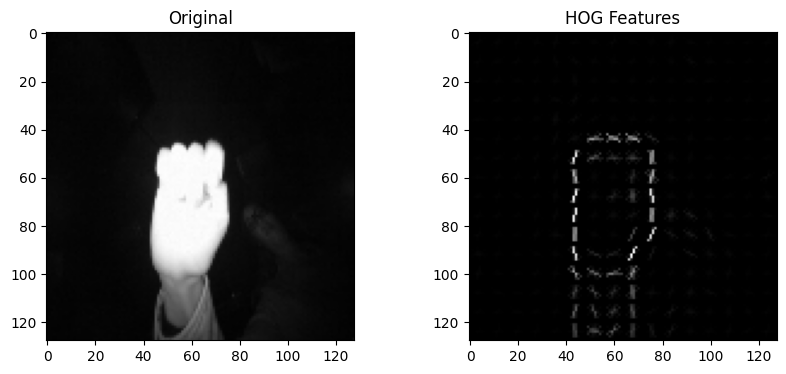

In [15]:
sample = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)

sample = cv2.resize(sample,(128,128))

fd, hog_image = hog(
    sample,
    visualize=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image,cmap='gray')
plt.title("HOG Features")

plt.show()

In [17]:
X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(651, 8100)
(163, 8100)


In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

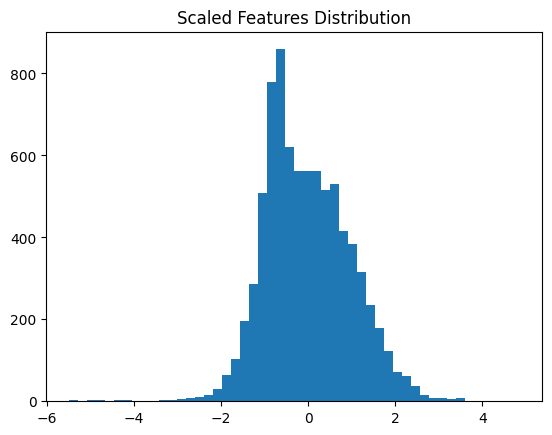

In [19]:
plt.hist(
    X_train[0],
    bins=50
)

plt.title("Scaled Features Distribution")
plt.show()

In [22]:
svm = SVC(
    kernel='rbf',
    probability=True
)

svm.fit(
    X_train,
    y_train
)
print("Training Completed!")

Training Completed!


In [24]:
y_pred = svm.predict(X_test)
print(y_pred[:20])

['02_l' '02_l' '01_palm' '02_l' '01_palm' '02_l' '02_l' '01_palm' '02_l'
 '01_palm' '02_l' '01_palm' '01_palm' '01_palm' '01_palm' '03_fist' '02_l'
 '01_palm' '02_l' '02_l']


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 100.00%


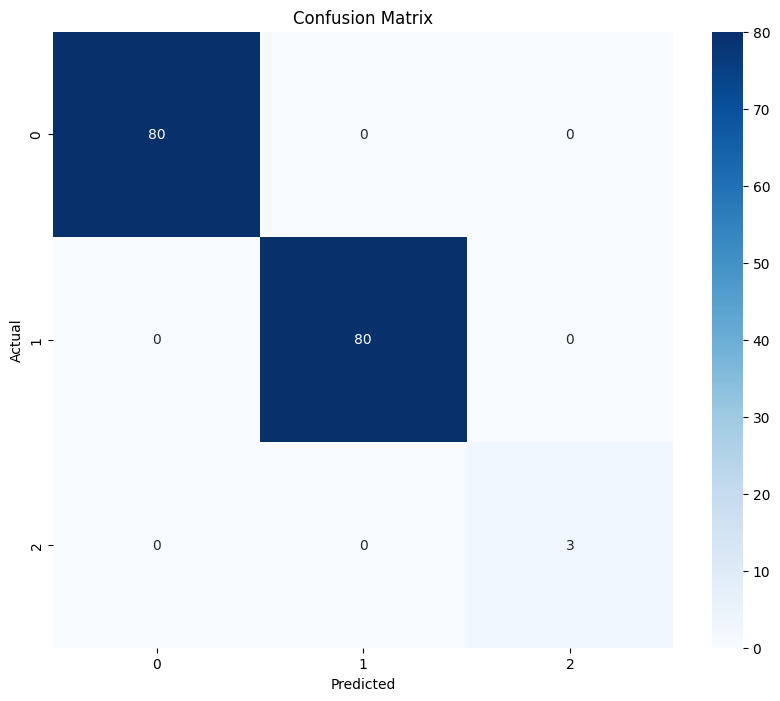

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     01_palm       1.00      1.00      1.00        80
        02_l       1.00      1.00      1.00        80
     03_fist       1.00      1.00      1.00         3

    accuracy                           1.00       163
   macro avg       1.00      1.00      1.00       163
weighted avg       1.00      1.00      1.00       163



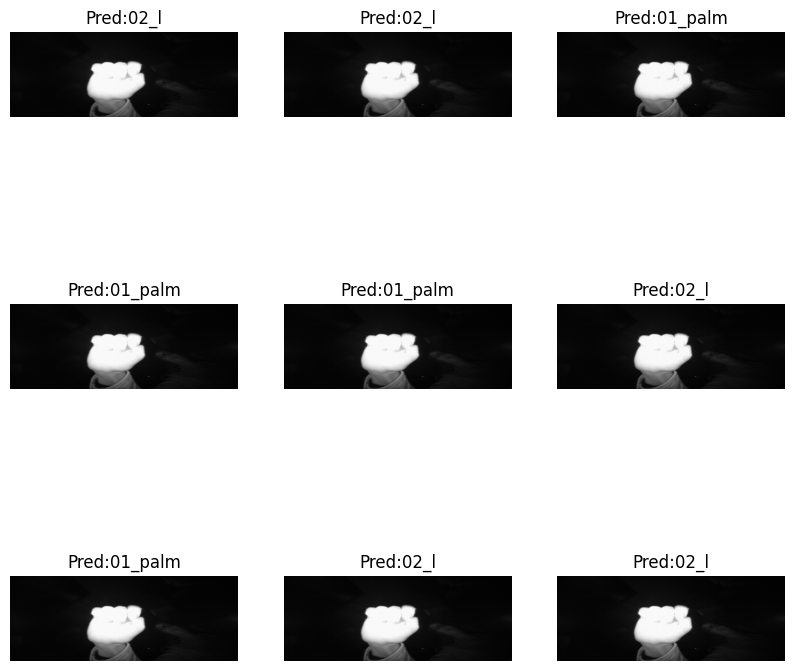

In [28]:
indices = np.random.choice(
    len(X_test),
    9
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)

for i, idx in enumerate(indices):

    img_path = img_path

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    axes[i//3,i%3].imshow(
        img,
        cmap='gray'
    )

    axes[i//3,i%3].set_title(
        f"Pred:{y_pred[idx]}"
    )

    axes[i//3,i%3].axis("off")

plt.show()

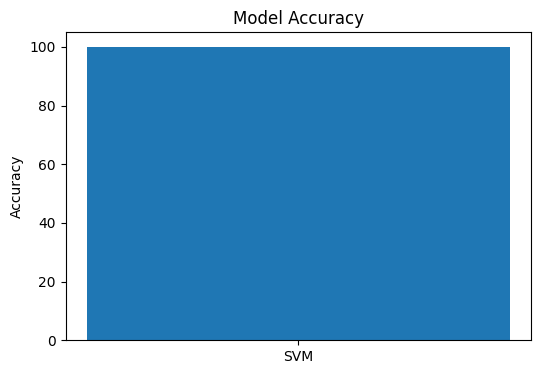

In [29]:
plt.figure(figsize=(6,4))

plt.bar(
    ["SVM"],
    [accuracy*100]
)

plt.ylabel("Accuracy")

plt.title(
    "Model Accuracy"
)

plt.show()

In [30]:
import pickle

pickle.dump(
    svm,
    open(
        "gesture_svm.pkl",
        "wb"
    )
)

In [31]:
print(f"Final Accuracy: {accuracy*100:.2f}%")
print("Model saved as gesture_svm.pkl")

Final Accuracy: 100.00%
Model saved as gesture_svm.pkl


In [32]:
import pickle
import os

pickle.dump(
    svm,
    open("gesture_svm.pkl", "wb")
)

print("="*40)
print("HAND GESTURE RECOGNITION PROJECT")
print("="*40)
print(f"Model Accuracy : {accuracy*100:.2f}%")
print("Model Saved Successfully")
print("File Name : gesture_svm.pkl")
print("Location :", os.getcwd())

HAND GESTURE RECOGNITION PROJECT
Model Accuracy : 100.00%
Model Saved Successfully
File Name : gesture_svm.pkl
Location : c:\Users\Dhanu Sree\OneDrive\Desktop\Internship\Task-4\Hand Gesture Recognition


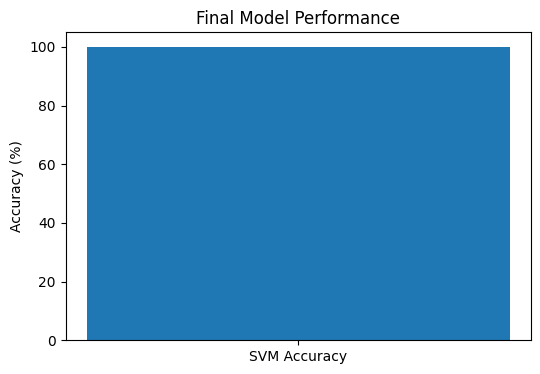

In [33]:
plt.figure(figsize=(6,4))

plt.bar(
    ["SVM Accuracy"],
    [accuracy*100]
)

plt.ylabel("Accuracy (%)")
plt.title("Final Model Performance")

plt.show()